In [1]:
import nibabel as nib
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [11]:
path = "/Users/daniel/Documents/CSAI/Thesis/ThesisCode/data/raw/"

files = os.listdir(path)

train_val, test_files = train_test_split(files, test_size=0.15, random_state=42)
train_files, val_files = train_test_split(train_val, test_size=0.15, random_state=42)

#reshaping the image to 224
def reshape(img):

    new_size = 224
    height = img.shape[0]
    width = img.shape[1]
    padding_value = img.min()

    #cropping anything larger than 224
    if height > new_size:
        img = img[(height//2)-(new_size//2):(height//2)+(new_size//2) ,: ,:]

    if width > new_size:
        img = img[:, (width//2)-(new_size//2):(width//2)+(new_size//2) ,:]

    #padding with minimum value if smaller than 224
    if height < new_size:

        pad_top = (new_size//2)-(height//2)
        pad_bottom = (new_size)-(height) - pad_top
        img = np.pad(img, ( (pad_top,pad_bottom), (0,0), (0,0) ), mode='constant', constant_values=padding_value)

    if width < new_size:

        pad_left = (new_size//2)-(width//2)
        pad_right = (new_size)-(width) - pad_left
        img = np.pad(img, ( (0,0), (pad_left,pad_right), (0,0) ), mode='constant', constant_values=padding_value)

    return img

#0-1 normalizing
def normalize(img):
    img = (img - img.min()) / (img.max() - img.min())
    return img

#generating the slices and saving them as numpy arrays
def dataset_generator(files, path, save_path):
    for nscan, file in enumerate(files):
        img = nib.load(os.path.join(path, file))
        np_img = np.asanyarray(img.dataobj, dtype=np.float32)
        np_img = reshape(np_img)
        np_img = normalize(np_img)
        print(np_img.shape)
        for nslice in range(np_img.shape[2]):
            np.save(f"{save_path}image_{nscan+1}_{nslice+1}", np_img[:,:,nslice])
            break


dataset_generator(train_files, path, "/Users/daniel/Documents/CSAI/Thesis/ThesisCode/data/train/")
dataset_generator(val_files, path, "/Users/daniel/Documents/CSAI/Thesis/ThesisCode/data/validation/")
dataset_generator(test_files, path, "/Users/daniel/Documents/CSAI/Thesis/ThesisCode/data/test/")

(224, 224, 431)
(224, 224, 440)
(224, 224, 486)
(224, 224, 394)
(224, 224, 407)


(224, 224)
0.5215686
0.054901976


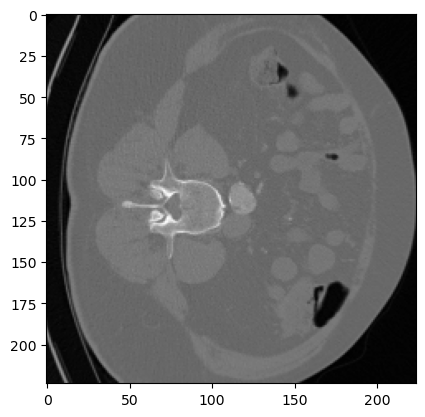

In [10]:
#img = nib.load("/Users/daniel/Documents/CSAI/Thesis/ThesisCode/data/raw/Scan_0011.nii")

np_img = np.load("/Users/daniel/Documents/CSAI/Thesis/ThesisCode/data/train/image_2_200.npy")

print(np_img.shape)
print(np_img.max())
print(np_img.min())

plt.figure()
plt.imshow(np_img, cmap='gray')